# Essay for Assignment, Course MZ340V17, 2025

This is an essay covering the [assignment](https://martinfleischmann.net/sds/micro/course_information/assignment.html) for [Course MZ340V17, 2025](https://martinfleischmann.net/sds/micro/).

## Parts Covered

This covers Part one and Part two, choosing option two of Part two.

# Part one

In [25]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import esda
import matplotlib.pyplot as plt
from libpysal import graph

## Derive Census Areas

The definition of census areas, `BarcelonaCiutat_SeccionsCensals.csv`, comes from ["Detail of administrative units of the city of Barcelona : districts, neighbourhoods, Interés area, basic statistical areas (AEB) and census areas"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/20170706-districtes-barris/resource/e16856a7-b3c0-4c32-a468-cc190cbbf7a9).

From looking through a sample of the datasets on the [Open Data BCN ](https://opendata-ajuntament.barcelona.cat/data/en/dataset) website, many of them have a "Seccio_Censal" column which is a combination of the District Code and the Census Code ("Seccio_Censal"), and so we use this definition here.

In [2]:
from shapely import from_wkt

def combine_districts_and_census_areas(df, district_column='codi_districte', census_column='codi_seccio_censal'):
    """Combines districts and census areas into a single column, `Seccio_Censal`."""
    df["Seccio_Censal"] = (
        (df[district_column] * 1000 ) + df[census_column]
    )

def barcelona_census_areas(url="BarcelonaCiutat_SeccionsCensals.csv"):
    """This loads the census areas as defined in a CSV file, and returns a 
    GDF with a single `Seccio_Censal` column and associated geometry.
    
    The `Seccio_Censal` column is the combination of the `codi_districte` and `codi_seccio_censal`.
    """
    df = pd.read_csv(url)
    combine_districts_and_census_areas(df)
    
    df["geometry"] = df["geometria_wgs84"].apply(from_wkt)
    df = df[["Seccio_Censal","geometry"]]
    
    assert df["Seccio_Censal"].is_unique
    df.set_index("Seccio_Censal")
    
    return gpd.GeoDataFrame(df,geometry="geometry",crs="EPSG:4326")


In [3]:
census_areas_gdf = barcelona_census_areas()

In [4]:
census_areas_gdf.head(2)

,Seccio_Censal,geometry
0,1001,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ..."
1,1002,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2...."


<Axes: >

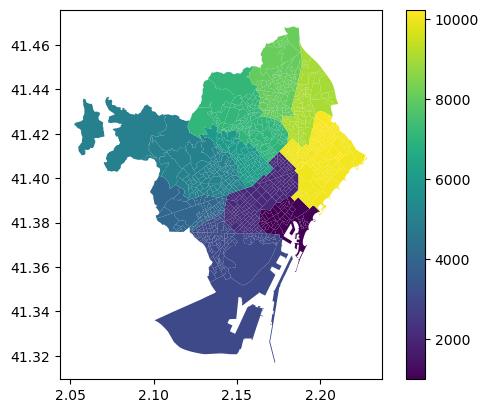

In [5]:
census_areas_gdf.plot("Seccio_Censal", legend=True)

## Choosing Socio-economic variables

There are many variables we could choose from. For simplicity we choose population and income to give both social and economic coverage:
* population is from ["Population of Barcelona according to the Municipal Register of Inhabitants on January 1 of each year"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018)
* income is from ["Average gross taxable income per person (€) in the city of Barcelona based on Atlas de distribución de la renta de los hogares of Instituto Nacional de Estadística (INE)"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/atles-renda-bruta-per-persona/resource/e6cabd96-68d6-451b-bc9f-c2a381d733e6)


In [8]:
def load_population_dataset(year):
    """Load population of Barcelona for a particular year; index is by `Seccio_Censal`.
    
    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_pad_mdbas.csv")
    df["population"] = df["Valor"].astype(float)
    df = df[["population","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

def load_income_dataset(year):
    """Load income of Barcelona for a particular year; index is by `Seccio_Censal`.

    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_atles_renda_bruta_persona.csv")
    df["income"] = df["Import_Renda_Bruta_€"].astype(float)
    combine_districts_and_census_areas(df, district_column='Codi_Districte',census_column='Seccio_Censal')
    
    df = df[["income","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

We choose a shared year that is the latest year both of the datasets are available.

In [9]:
shared_year=2023

population_df = load_population_dataset(shared_year)
population_df.head(2)

,population,Seccio_Censal
0,1246.0,1001
1,1238.0,1002


In [11]:
income_df = load_income_dataset(shared_year)
income_df.head(2)

,income,Seccio_Censal
0,17113.0,1001
1,13081.0,1002


### Removing extremes

Both the datasets have some extreme values, which will easily bias later calculations that are based on `mean`, so we pre-filter the datasets to remove any values > 3 standard deviations away from mean.

In [12]:
def std_dev(df, column, std_column=None):
    std_df = df.copy(deep=True)
    if std_column is None:
        std_column = f"{column}_std"
    
    std_df[std_column] = (
        std_df[column] - std_df[column].mean()
    ) / std_df[column].std()

    return std_df

def filter_extremes(df, column, max_abs_std=3):
    """filters out rows which are more than `max_abs_std` deviations away from zero."""
    std_column = f"{column}_std"
    std_df = std_dev(df, column, std_column = std_column)
    std_df = std_df[
        (std_df[std_column] >= (-1 * max_abs_std))
        & (std_df[std_column] <= max_abs_std)
    ]
    return std_df.drop(std_column, axis=1)

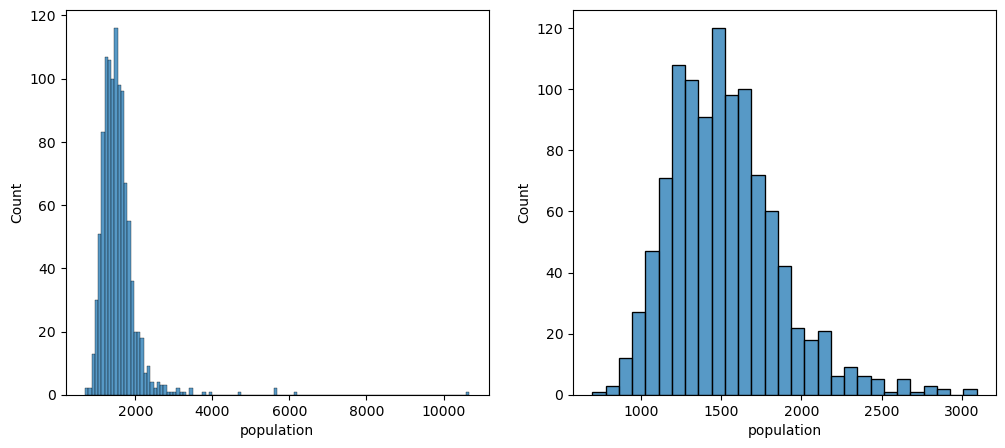

In [17]:
population_filtered_df = filter_extremes(population_df, column="population")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(population_df["population"], ax=axs[0])
sns.histplot(population_filtered_df["population"], ax=axs[1])
plt.show()

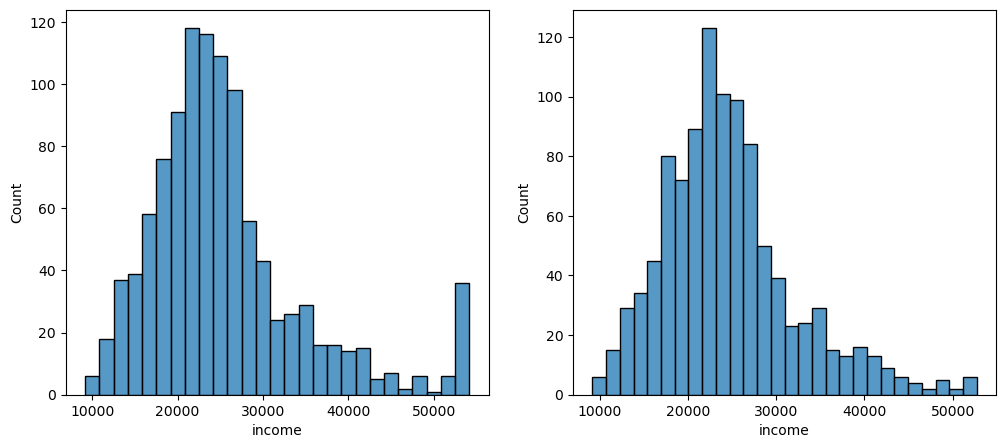

In [18]:
income_filtered_df = filter_extremes(income_df, column="income")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(income_df["income"], ax=axs[0])
sns.histplot(income_filtered_df["income"], ax=axs[1])
plt.show()

## Merge with Census Areas

We can now merge these into the census areas to produce one GeoDataFrame for our analysis

In [19]:
def merge_in_dataframes(gdf, dfs):
    """Merge multiple DataFrames into a GeoDataFrame, based on index."""
    merged_gdf = gdf
    for df in dfs:
        merged_gdf = merged_gdf.merge(df)
    return merged_gdf

In [21]:
barcelona_gdf = merge_in_dataframes(census_areas_gdf, dfs=[population_filtered_df,income_filtered_df])
barcelona_gdf.head(2)

,Seccio_Censal,geometry,population,income
0,1001,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ...",1246.0,17113.0
1,1002,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2....",1238.0,13081.0


## Analysis

If we examine the chloropleths of each variable by eye we see a couple of things:
* for population, there appear to be a small number of areas with a lot of people, but apart from that there aren't many clear patterns
* for income, we see a few hotspots, particularly on the left-hand side, in an approximate "V" shape

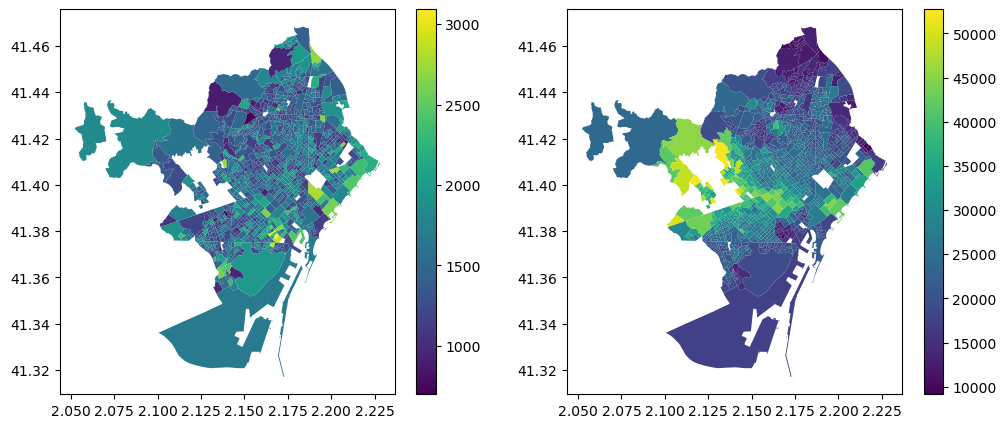

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
barcelona_gdf.plot("population", ax=axs[0], legend=True)
barcelona_gdf.plot("income", ax=axs[1], legend=True)
plt.show()

## Moran's I

To get a more rigorous idea of structure, we will first apply Moran I's at Global level. For each area, this takes a value of a variable in an area and compares it against the spatially-lagged value for the neighhourhood (contiguity) of that area.

In our definition here, because we are using the row-standardized contiguity for a census area, we end up with the spatially-lagged average population or income of each census area.


In [31]:
def build_averaging_queen_contiguity(gdf):
    """build a Queen contiguity that is transformed to support averaging across nieghbours"""
    contiguity = graph.Graph.build_contiguity(gdf, rook=False)
    contiguity_r = contiguity.transform("r")

    return contiguity_r

def moran_global(gdf, column, crit_value=0.05):
    """Does a Global Spatial analysis using Moran's I for this dataset, and returns a plot 
    illustrating what is happening internally.
    """
 
    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    # get ESDA to do the actual analysis
    moran = esda.Moran(gdf[column], contiguity_r)
    print(f"I: {moran.I}, P_sim: {moran.p_sim}, <{crit_value}?: {moran.p_sim < crit_value}")

    # redo the analysis as a visualisation
    std_column = f"{column}_std"
    lag_column = f"{column}_std_lag"
    std_gdf = std_dev(gdf, column, std_column=std_column)
    std_gdf[lag_column] = contiguity_r.lag(std_gdf[std_column])

    f, ax = plt.subplots(1, figsize=(6, 6))
    sns.regplot(
        x=std_column,
        y=lag_column,
        data=std_gdf,
        marker=".",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="lightcoral")
    )
    ax.set_aspect('equal')
    plt.axvline(0, c="black", alpha=0.5)
    plt.axhline(0, c="black", alpha=0.5)

I: 0.20797380565062407, P_sim: 0.001, <0.05?: True


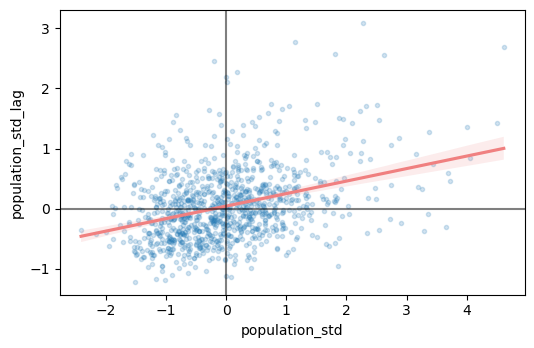

In [33]:
moran_global(barcelona_gdf, "population")

I: 0.8053386338527503, P_sim: 0.001, <0.05?: True


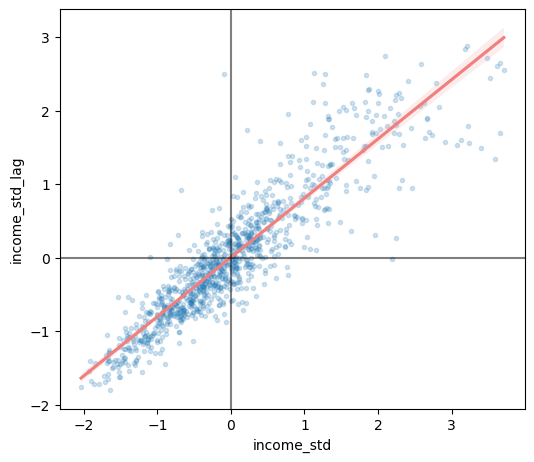

In [34]:
moran_global(barcelona_gdf, "income")

For both of these, because `P_sim` is less than 0.05 (5%), we can discount the null hypothesis that this correlation is random i.e. this is a real effect.

The value of Moran's I is greater for income than for population, which is consistent with our previous intuition: income is more spatially-correlated than population.

## LISA (using Moran Local)

So, we have confidence that there are cluster, but we are also interested in what this looks on the actual map. For this we will use a LISA (Local Indicator of Spatial autocorrelation): Moran Local.

In [70]:
def moran_local_clusters(gdf, column, crit_value):
    """Does a Local Spatial analysis using Moran Local for this dataset, and returns the clusters."""

    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    lisa_gdf = gdf.copy(deep=True)
    lisa = esda.Moran_Local(lisa_gdf[column], contiguity_r)

    lisa_gdf['cluster'] = lisa.get_cluster_labels(crit_value=crit_value)
    return lisa, lisa_gdf

In [71]:
crit_value=0.05
barcelona_population_lisa, barcelona_population_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "population", crit_value)
barcelona_income_lisa, barcelona_income_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "income", crit_value)

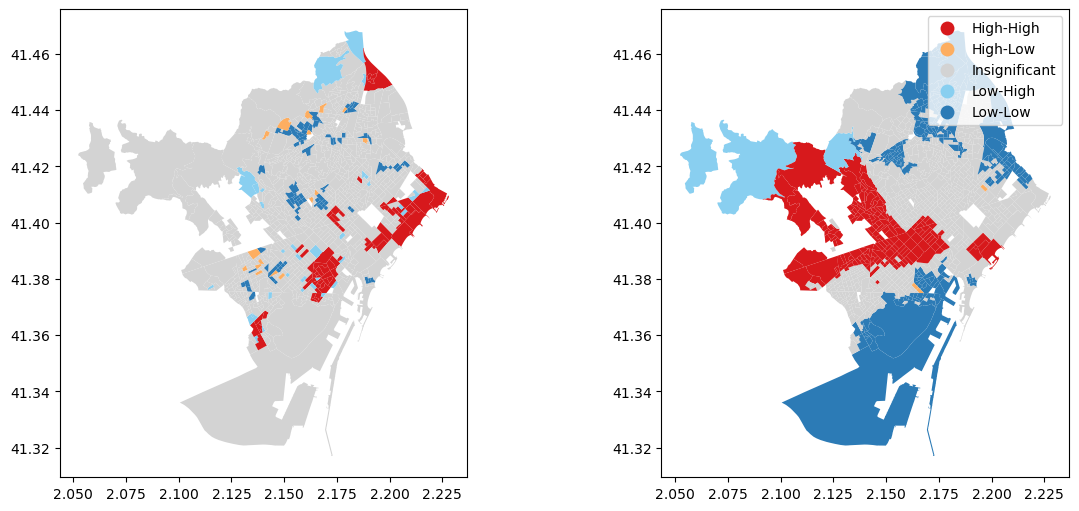

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
barcelona_population_lisa.plot(
    barcelona_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_income_lisa.plot(
    barcelona_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=True
)
plt.show()

From this we can see that:
* for population, there are large clusters of high-high population areas, near the center of barcelona and on the coastline, with the other cluster types less present
* for income, there is a mix of high-high (including the V-shape we saw previously and some next to the sea), with low-low areas on north and south. There are also a couple of areas on the outskirts at north-west that are low-high